In [1]:
# Execute this code block to install dependencies when running on colab
try:
    import torch
except:
    from os.path import exists
    from wheel.pep425tags import get_abbr_impl, get_impl_ver, get_abi_tag
    platform = '{}{}-{}'.format(get_abbr_impl(), get_impl_ver(), get_abi_tag())
    cuda_output = !ldconfig -p|grep cudart.so|sed -e 's/.*\.\([0-9]*\)\.\([0-9]*\)$/cu\1\2/'
    accelerator = cuda_output[0] if exists('/dev/nvidia0') else 'cpu'

    !pip install -q http://download.pytorch.org/whl/{accelerator}/torch-1.0.0-{platform}-linux_x86_64.whl torchvision

# Part 3: Variational Autoencoders (VAE)

For this part of the lab, you will implement a VAE. There is some code below which will help you run the learning procedure, however, you will need to complete the definition of the loss function. Start by implementing the encoder and decoder for the VAE. There is a diagram below illustrating what these architectures should look like.

Let's start by loading the Fashion-MNIST dataset again and transforming the data to a flattened tensor.

### Loading the Dataset

In [3]:
%matplotlib inline

import torchvision
import torchvision.transforms as transforms

batch_size = 256
image_dim = 784 #flattened

# dataset construction
transform = transforms.Compose([
    transforms.ToTensor(), # convert to tensor
    transforms.Lambda(lambda x: x.view(image_dim)) # flatten into vector
    ])

train_set = torchvision.datasets.FashionMNIST(
    root='./data/FashionMNIST'
    ,train=True
    ,download=True
    ,transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=batch_size
)

## Build a Simple Variational Autoencoder

<img src="https://ecs-vlc.github.io/COMP6258/labs/lab8/VAE_resized.png">

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from tqdm.autonotebook import tqdm
from itertools import chain

import numpy as np

class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Encoder, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super(Decoder, self).__init__()
        self.fc1 = nn.Linear(latent_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))  # Sigmoid for output between 0 and 1
        return x

<ipython-input-4-b330543bb244>:6: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


## You may complete the code below to test your implementation, or alternately, rewrite your own.

#### Once you've trained the network plot some reconstructions side-by-side with the original images and reflect on how good the reconstructions are (or aren't!). Also try generating some random images by sampling the prior and feeding the vectors to the decoder.

  0%|          | 0/235 [00:00<?, ?it/s]

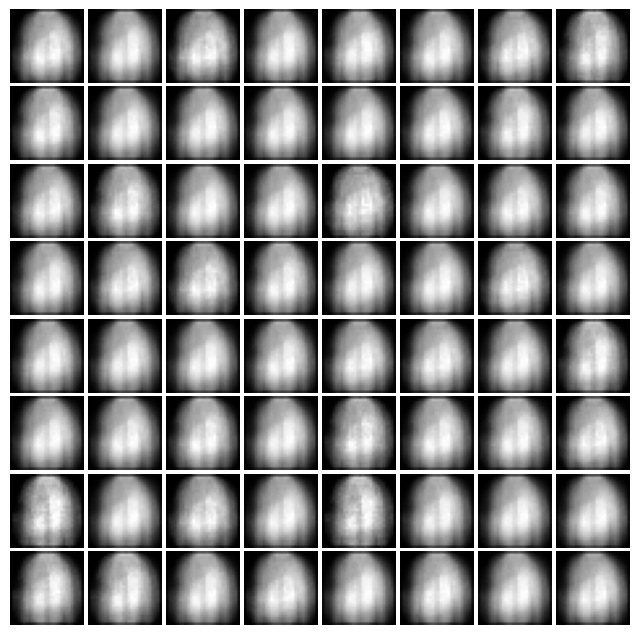

  0%|          | 0/235 [00:00<?, ?it/s]

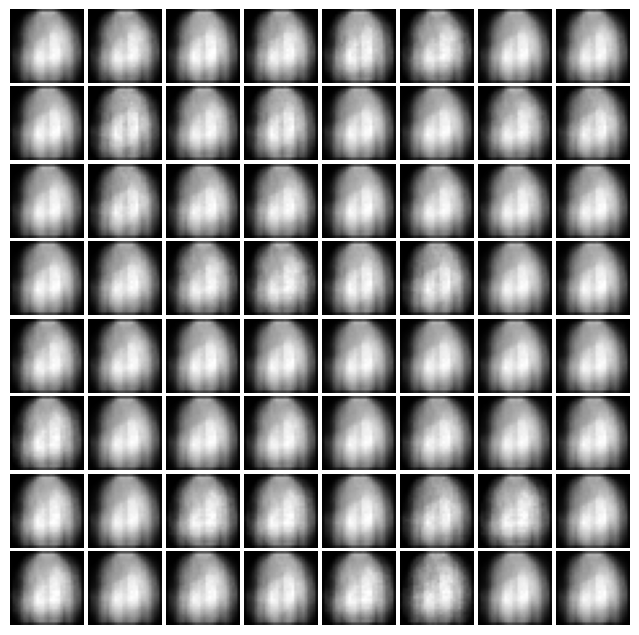

  0%|          | 0/235 [00:00<?, ?it/s]

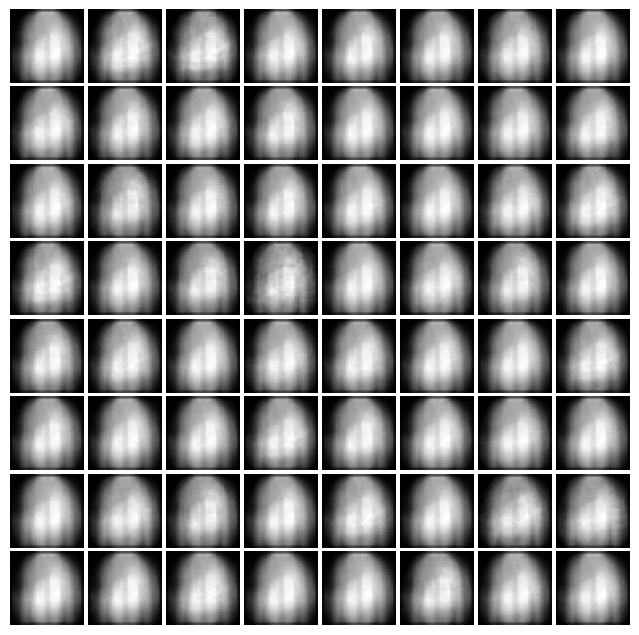

  0%|          | 0/235 [00:00<?, ?it/s]

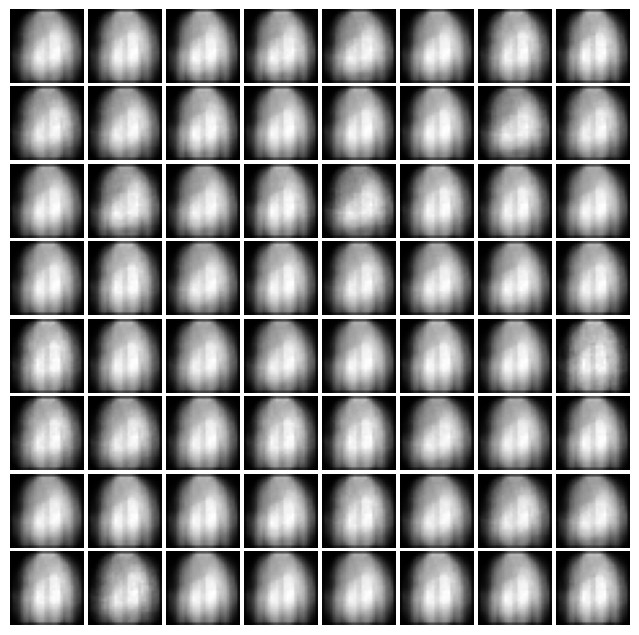

  0%|          | 0/235 [00:00<?, ?it/s]

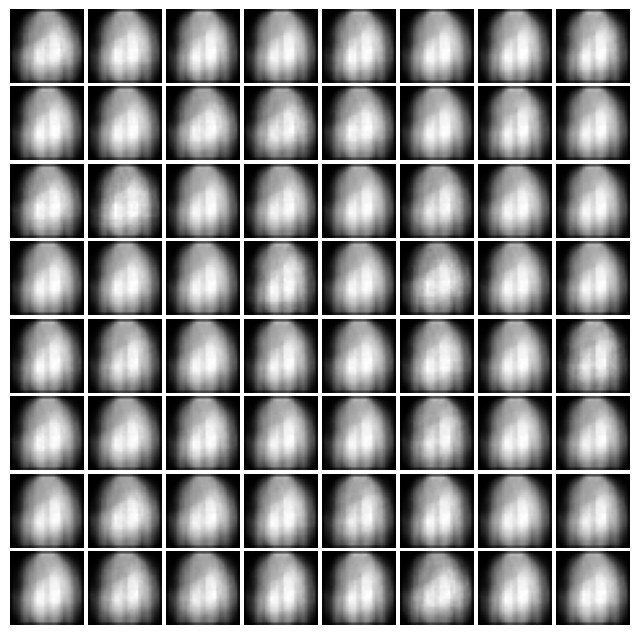

  0%|          | 0/235 [00:00<?, ?it/s]

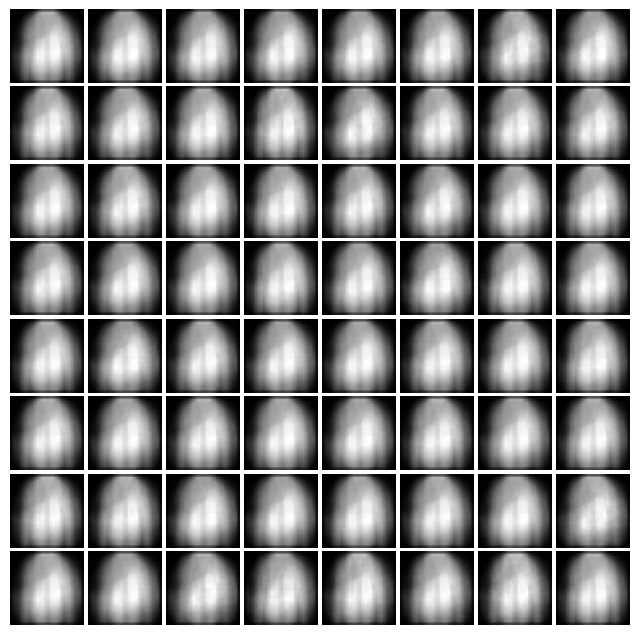

  0%|          | 0/235 [00:00<?, ?it/s]

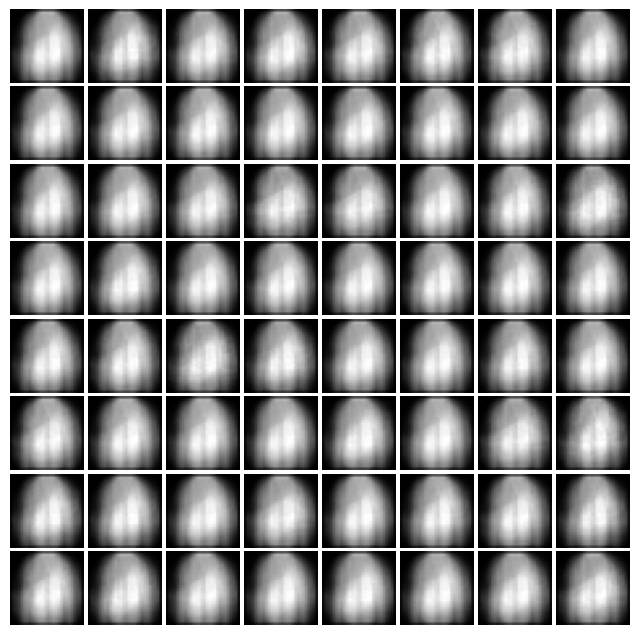

  0%|          | 0/235 [00:00<?, ?it/s]

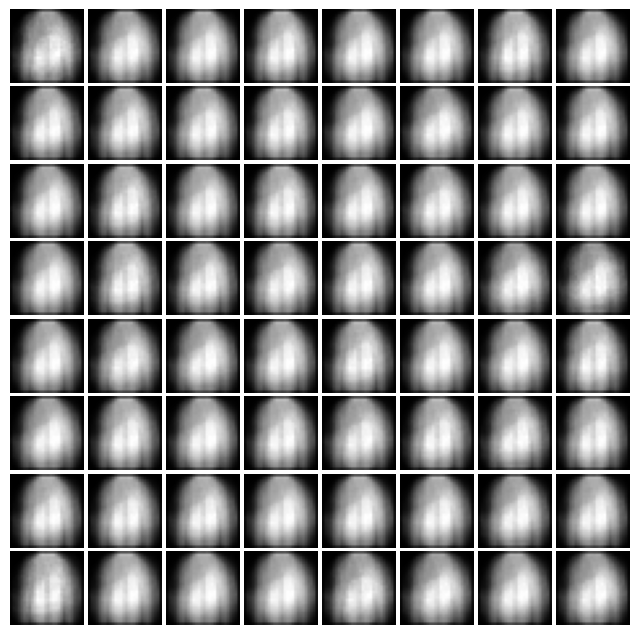

  0%|          | 0/235 [00:00<?, ?it/s]

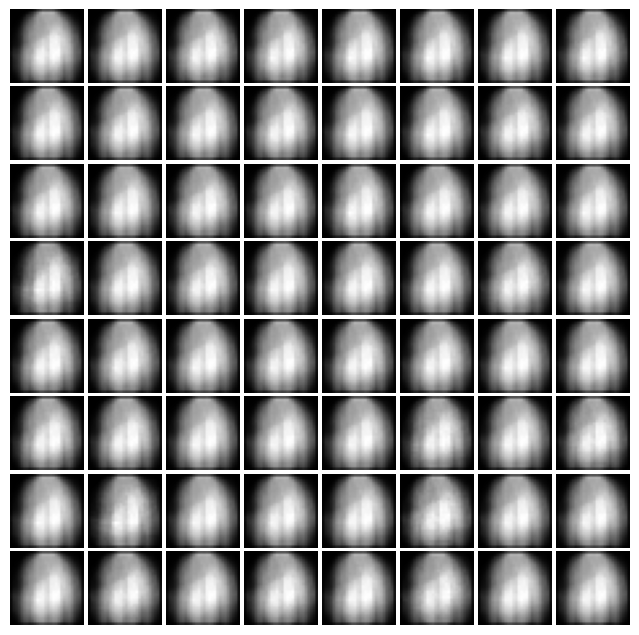

  0%|          | 0/235 [00:00<?, ?it/s]

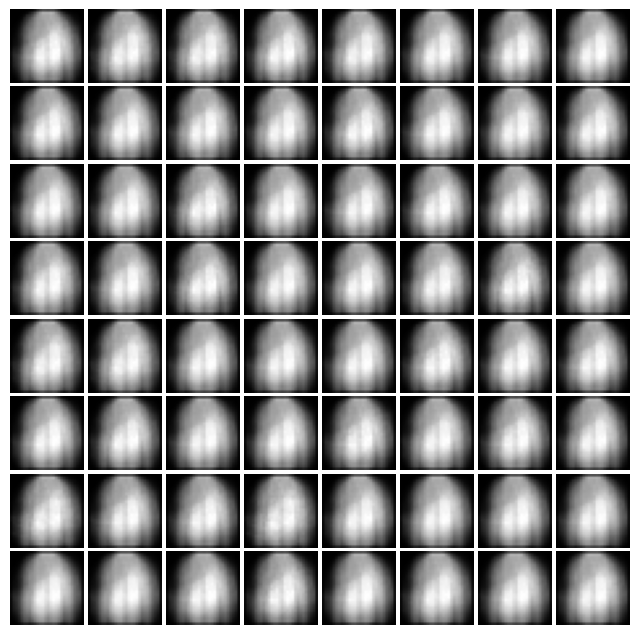

In [7]:
import matplotlib.gridspec as gridspec
import os
import matplotlib.pyplot as plt

# Sampling function (using the reparameterisation trick)
def sample_latent(mu, log_var):
    std = torch.exp(0.5 * log_var)
    eps = torch.randn_like(std)
    return mu + eps * std
#parameters
batch_size = 256
embedding_dim = 2
enc_hidden_units = 512
dec_hidden_units = 512
nEpoch = 10

# construct the encoder, decoder and optimiser
enc = Encoder(image_dim, enc_hidden_units, embedding_dim)
dec = Decoder(embedding_dim, dec_hidden_units, image_dim)
optimizer = optim.Adam(chain(enc.parameters(), dec.parameters()), lr=1e-3)

for epoch in range(nEpoch):
    losses = []
    trainloader = tqdm(train_loader)

    for i, data in enumerate(trainloader, 0):
        inputs, _ = data

        optimizer.zero_grad()

        mu, log_sigma2 = enc(inputs)
        z = sample_latent(mu, log_sigma2)
        outputs = dec(z)

        recon = F.binary_cross_entropy(outputs, inputs, reduction='sum') / inputs.shape[0]

        # Calculate KL divergence
        kl = -0.5 * torch.sum(1 + log_sigma2 - mu.pow(2) - log_sigma2.exp())

        loss = recon + kl
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        trainloader.set_postfix(loss=np.mean(losses), epoch=epoch)

    # Display generated images
    with torch.no_grad():
        z = torch.randn(64, embedding_dim)
        samples = dec(z)
        samples = samples.view(64, 1, 28, 28)

        fig = plt.figure(figsize=(8, 8))
        gs = gridspec.GridSpec(8, 8)
        gs.update(wspace=0.05, hspace=0.05)

        for i, sample in enumerate(samples):
            ax = plt.subplot(gs[i])
            plt.axis('off')
            ax.set_xticklabels([])
            ax.set_yticklabels([])
            ax.set_aspect('equal')
            plt.imshow(sample.squeeze(), cmap='gray')

        plt.show()

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np

In [6]:
# 超参数设置
LATENT_DIM = 2
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 128

# 数据加载
transform = transforms.ToTensor()
train_loader = torch.utils.data.DataLoader(
    torchvision.datasets.FashionMNIST('./data', train=True, download=True, transform=transform),
    batch_size=BATCH_SIZE, shuffle=True)

100%|██████████| 26.4M/26.4M [00:03<00:00, 8.28MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 135kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.52MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 8.38MB/s]


In [7]:
class VAE(nn.Module):
    def __init__(self):
        super(VAE, self).__init__()
        self.fc1 = nn.Linear(28*28, 400)
        self.fc21 = nn.Linear(400, LATENT_DIM)
        self.fc22 = nn.Linear(400, LATENT_DIM)
        self.fc3 = nn.Linear(LATENT_DIM, 400)
        self.fc4 = nn.Linear(400, 28*28)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        return self.fc21(h), self.fc22(h)  # 均值和对数方差

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 28*28))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# VAE loss 函数
def vae_loss(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 28*28), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

[VAE] Epoch 1, Loss: 293.5113
[VAE] Epoch 2, Loss: 272.9767
[VAE] Epoch 3, Loss: 269.5290
[VAE] Epoch 4, Loss: 267.6443
[VAE] Epoch 5, Loss: 266.3098


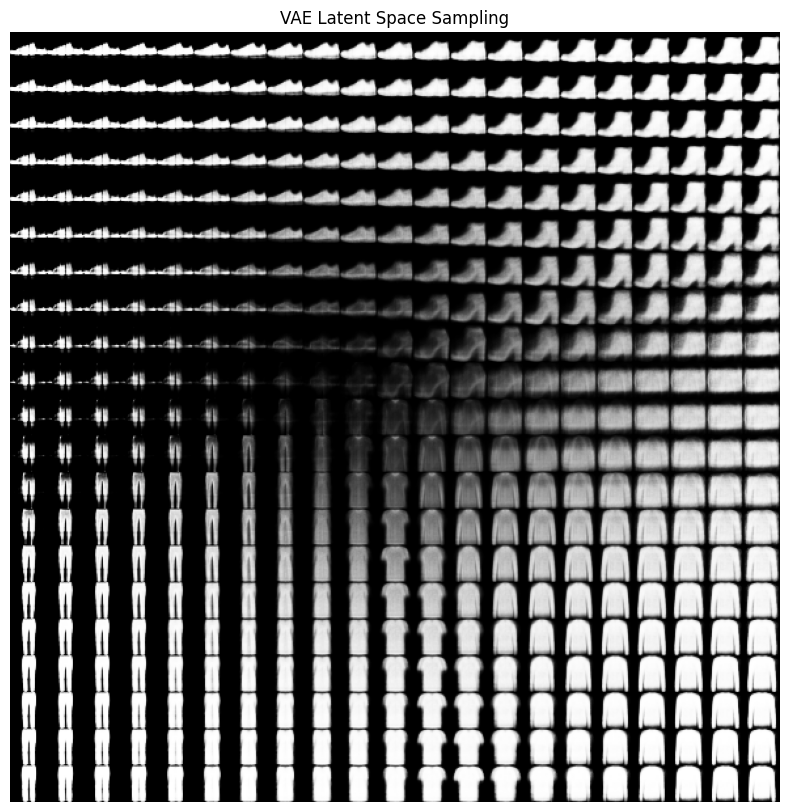

In [11]:
vae = VAE().to(DEVICE)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)
np.random.seed(0)
torch.manual_seed(0)
vae.train()
for epoch in range(5):
    total_loss = 0
    for x, _ in train_loader:
        x = x.to(DEVICE)
        optimizer.zero_grad()
        recon, mu, logvar = vae(x)
        loss = vae_loss(recon, x, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f'[VAE] Epoch {epoch+1}, Loss: {total_loss/len(train_loader.dataset):.4f}')

# -----------------------
# 系统采样潜空间并可视化 VAE
# -----------------------
def plot_latent_space(decoder, model_name):
    n = 21
    digit_size = 28
    scale = 4  # 范围是 [-4, 4]

    # 创建空画布
    figure = np.zeros((digit_size * n, digit_size * n))

    # z 向量的两个维度：x 从左到右（-4 到 4），y 从上到下（4 到 -4）
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(scale, -scale, n)

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z = torch.tensor([[xi, yi]], dtype=torch.float32).to(DEVICE)
            with torch.no_grad():
                out = decoder(z)
            digit = out.view(digit_size, digit_size).cpu().numpy()
            figure[i * digit_size: (i + 1) * digit_size,
                   j * digit_size: (j + 1) * digit_size] = digit

    # 显示图像
    plt.figure(figsize=(10, 10))
    plt.imshow(figure, cmap='gray')
    plt.axis('off')
    plt.title(f"{model_name} Latent Space Sampling")
    plt.show()

# 可视化 VAE 潜空间
vae.eval()
plot_latent_space(vae.decode, "VAE")

[AE] Epoch 1, Loss: 31.5986
[AE] Epoch 2, Loss: 24.1694
[AE] Epoch 3, Loss: 23.3258
[AE] Epoch 4, Loss: 22.8838
[AE] Epoch 5, Loss: 22.5763


NameError: name 'save_path' is not defined

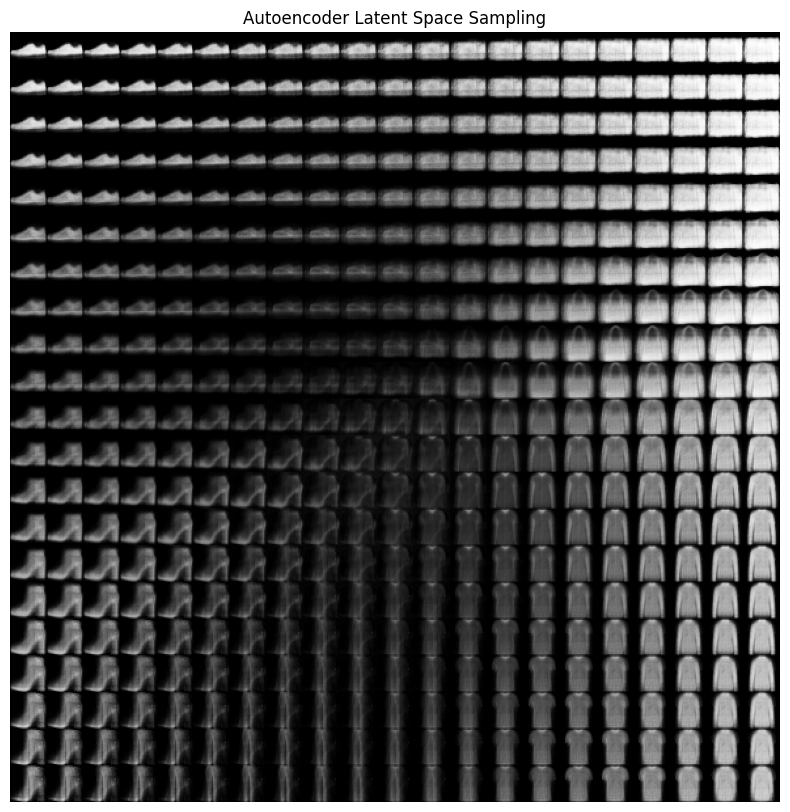

In [10]:
np.random.seed(0)
torch.manual_seed(0)
class AE(nn.Module):
    def __init__(self):
        super(AE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28*28, 400),
            nn.ReLU(),
            nn.Linear(400, LATENT_DIM)
        )
        self.decoder = nn.Sequential(
            nn.Linear(LATENT_DIM, 400),
            nn.ReLU(),
            nn.Linear(400, 28*28),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x.view(-1, 28*28))
        out = self.decoder(z)
        return out

# -----------------------
# 训练 Autoencoder
# -----------------------
ae = AE().to(DEVICE)
optimizer = torch.optim.Adam(ae.parameters(), lr=1e-3)
loss_fn = nn.MSELoss(reduction='sum')

ae.train()
for epoch in range(5):
    total_loss = 0
    for x, _ in train_loader:
        x = x.to(DEVICE)
        optimizer.zero_grad()
        out = ae(x)
        loss = loss_fn(out, x.view(-1, 28*28))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f'[AE] Epoch {epoch+1}, Loss: {total_loss/len(train_loader.dataset):.4f}')

# 可视化 Autoencoder 潜空间
ae.eval()
plot_latent_space(ae.decoder, "Autoencoder")